In [1]:
%%capture
%pip -q install wotan transitleastsquares

In [2]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import clear_output

import json
import yaml

import copy
import os
import subprocess
import sys
import time

import tempfile
import h5py

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

from wotan import flatten

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['olivedrab', 'steelblue', 'firebrick', 'goldenrod'])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [15]:
import h5py

# Open the HDF5 file
file_path = 'PSLS/data/trainPlanet.hdf5'
f = h5py.File(file_path, 'r')

# View root-level keys
print(list(f.keys()))

['run_00003', 'run_00006', 'run_00007', 'run_00008', 'run_00009', 'run_00011', 'run_00016', 'run_00017', 'run_00021', 'run_00023', 'run_00026', 'run_00029', 'run_00030', 'run_00031', 'run_00035', 'run_00039', 'run_00042', 'run_00043', 'run_00047', 'run_00055', 'run_00057', 'run_00059', 'run_00060', 'run_00061', 'run_00062', 'run_00063', 'run_00074', 'run_00075', 'run_00077', 'run_00080', 'run_00082', 'run_00086', 'run_00088', 'run_00090', 'run_00091', 'run_00093', 'run_00105', 'run_00107', 'run_00109', 'run_00112', 'run_00115', 'run_00117', 'run_00118', 'run_00119', 'run_00120', 'run_00125', 'run_00129', 'run_00132', 'run_00133', 'run_00138', 'run_00148', 'run_00152', 'run_00156', 'run_00158', 'run_00160', 'run_00164', 'run_00169', 'run_00170', 'run_00171', 'run_00176', 'run_00181', 'run_00182', 'run_00184', 'run_00187', 'run_00188', 'run_00191', 'run_00193', 'run_00195', 'run_00197', 'run_00207', 'run_00213', 'run_00215', 'run_00216', 'run_00217', 'run_00219', 'run_00224', 'run_00226'

399564


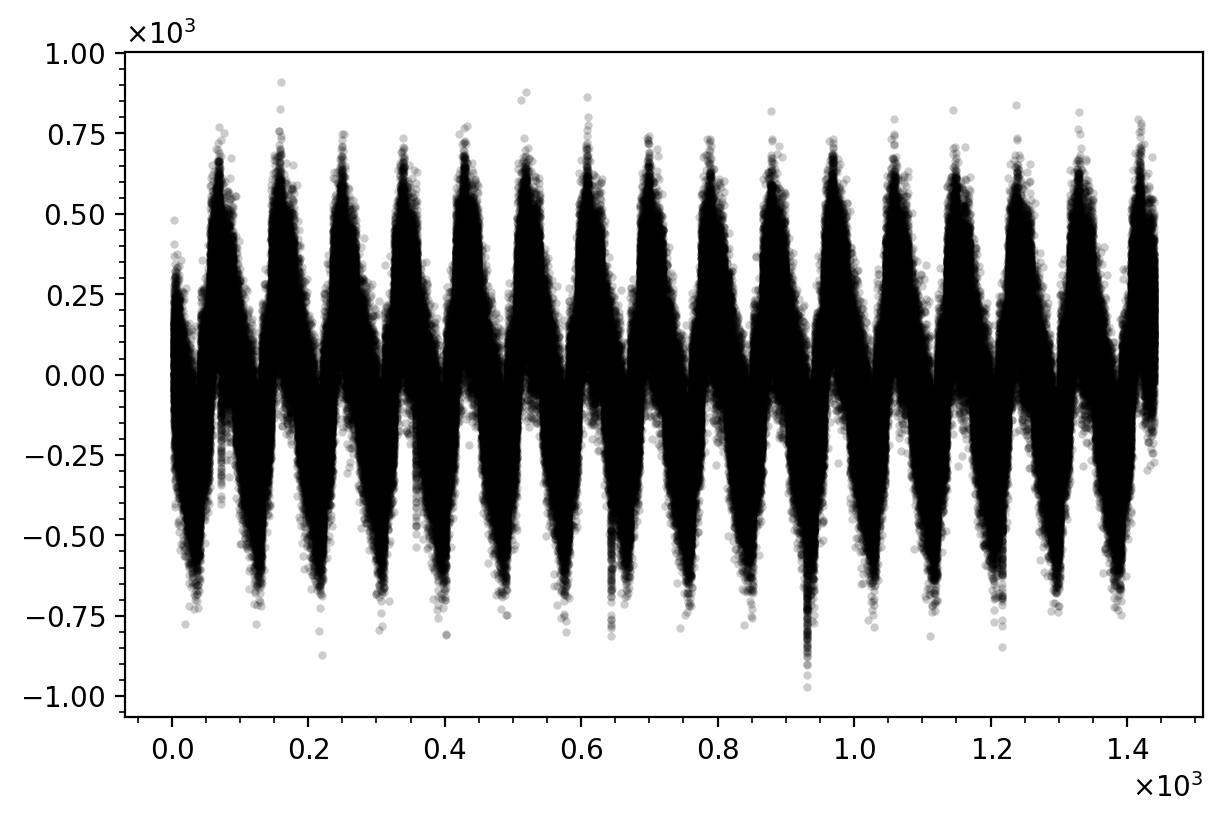

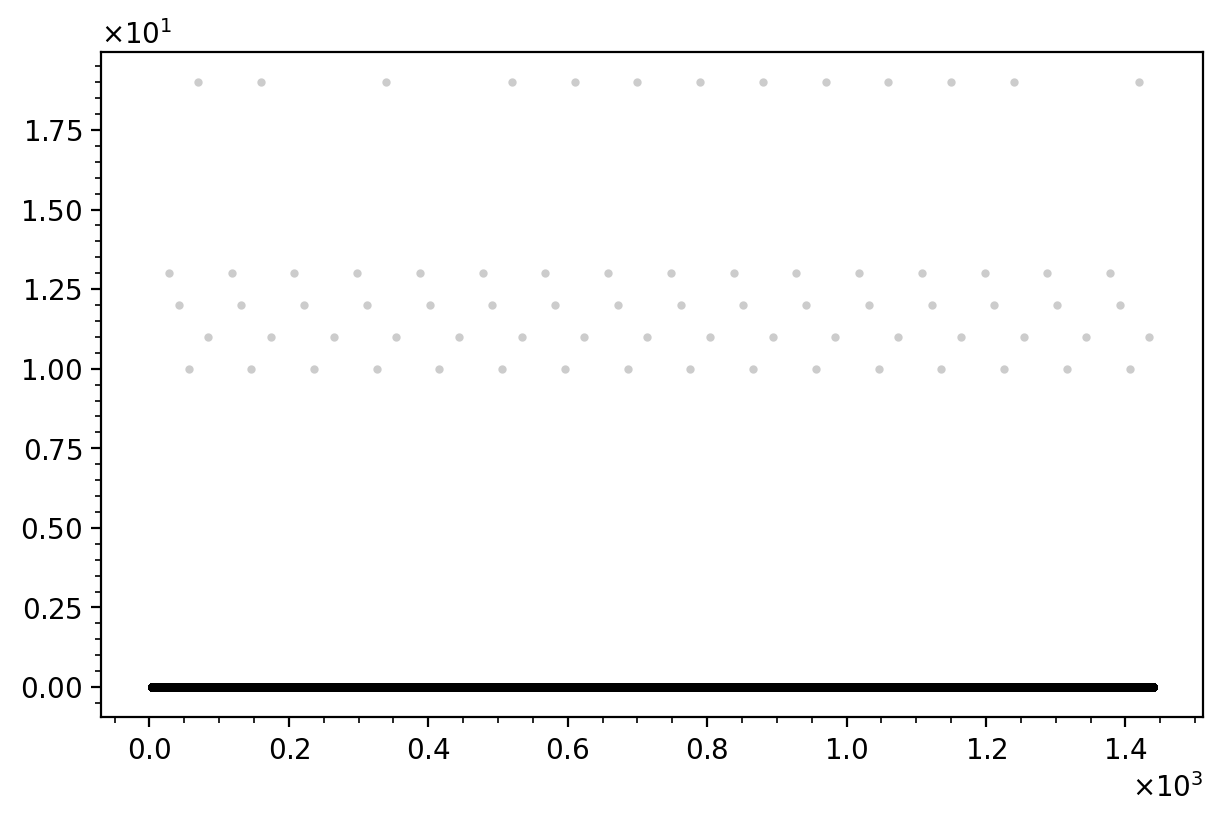

ValueError: zero-size array to reduction operation minimum which has no identity

In [106]:
# Access a specific group (if applicable)
# group = f['group_name']
# print("Keys in group:", list(group.keys()))

index = '00004'

# Access a dataset directly
flag, flux, time = f[f'run_{index}/dat/flag'][:], f[f'run_{index}/dat/flux_var_ppm'][:], f[f'run_{index}/dat/time_s'][:] / (60 * 60 * 24)

print(len(time))

lo, hi = 15100, 23350

plt.plot(time, flux, 'k.', mec='none', alpha = 0.2)
plt.show()

plt.plot(time, flag, 'k.', mec='none', alpha = 0.2)
plt.show()

mask = np.argwhere(flag != 0.0).flatten()

WINDOW = 1.5
EDGE = 0.5

detrend = np.array([])
trend = np.array([])

lo, hi = 0, 0
for ind in mask:
    bhi = ind
    tmp_detr, tmp_tr = flatten(
        time=time[lo:hi],
        flux=flux[lo:hi],
        method='biweight',
        window_length=WINDOW,
        edge_cutoff=EDGE,
        return_trend=True
    )
    lo = ind
    detrend, trend = np.append(detrend, tmp_detr), np.append(trend, tmp_tr)

#flatten_flux, trend_flux = flatten(
#    time=time, 
#    flux=flux, 
#    window_length=WINDOW, 
#    method='biweight',
#    edge_cutoff=EDGE,
#    return_trend=True
#)

#flatten_flux, trend_flux
detrend, trend

In [4]:
import numpy as np
from wotan import flatten

# 1. Isolate the exact indices where flags are raised
mask = np.where(flag != 0.0)[0]

# 2. Build explicit chunk boundaries from index 0 to the absolute end of the array
split_indices = [0] + list(mask) + [len(time)]

# Use lists to accumulate arrays (vastly faster than np.append in a loop)
detrend_chunks = []
trend_chunks = []

WINDOW = 1.5
EDGE = 0.5

# 3. Clean slice iterations using pairs of sequential boundaries
for lo, hi in zip(split_indices[:-1], split_indices[1:]):
    
    # Handle single-point flags or empty slices safely without crashing
    if (hi - lo) <= 1:
        detrend_chunks.append(np.array([np.nan] * (hi - lo)))
        trend_chunks.append(np.array([np.nan] * (hi - lo)))
        continue
        
    t_chunk = time[lo:hi]
    f_chunk = flux[lo:hi]
    
    chunk_duration = t_chunk[-1] - t_chunk[0]
    
    # --- DYNAMIC PARAMETER PROTECTION ---
    # If a chunk is shorter than your combined edge cutoffs (1.0 day),
    # drop the edge cutoff for this chunk to prevent a total NaN wipeout.
    current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
    
    # If a chunk is narrower than your window length, scale the window down
    current_window = WINDOW
    if chunk_duration <= WINDOW:
        current_window = chunk_duration / 2.0
        if current_window < 0.1:  # Absolute safety floor
            current_window = 0.1
    # ------------------------------------
    
    # Process the safe chunk
    tmp_detr, tmp_tr = flatten(
        time=t_chunk,
        flux=f_chunk,
        method='biweight',
        window_length=current_window,
        edge_cutoff=current_edge,
        return_trend=True
    )
    
    detrend_chunks.append(tmp_detr)
    trend_chunks.append(tmp_tr)

# 4. Stitch everything back together into continuous arrays seamlessly
detrend = np.concatenate(detrend_chunks)
trend = np.concatenate(trend_chunks)

detrend

NameError: name 'flag' is not defined

Total processed shape: (399558,)
Number of valid numbers in trend: 362768


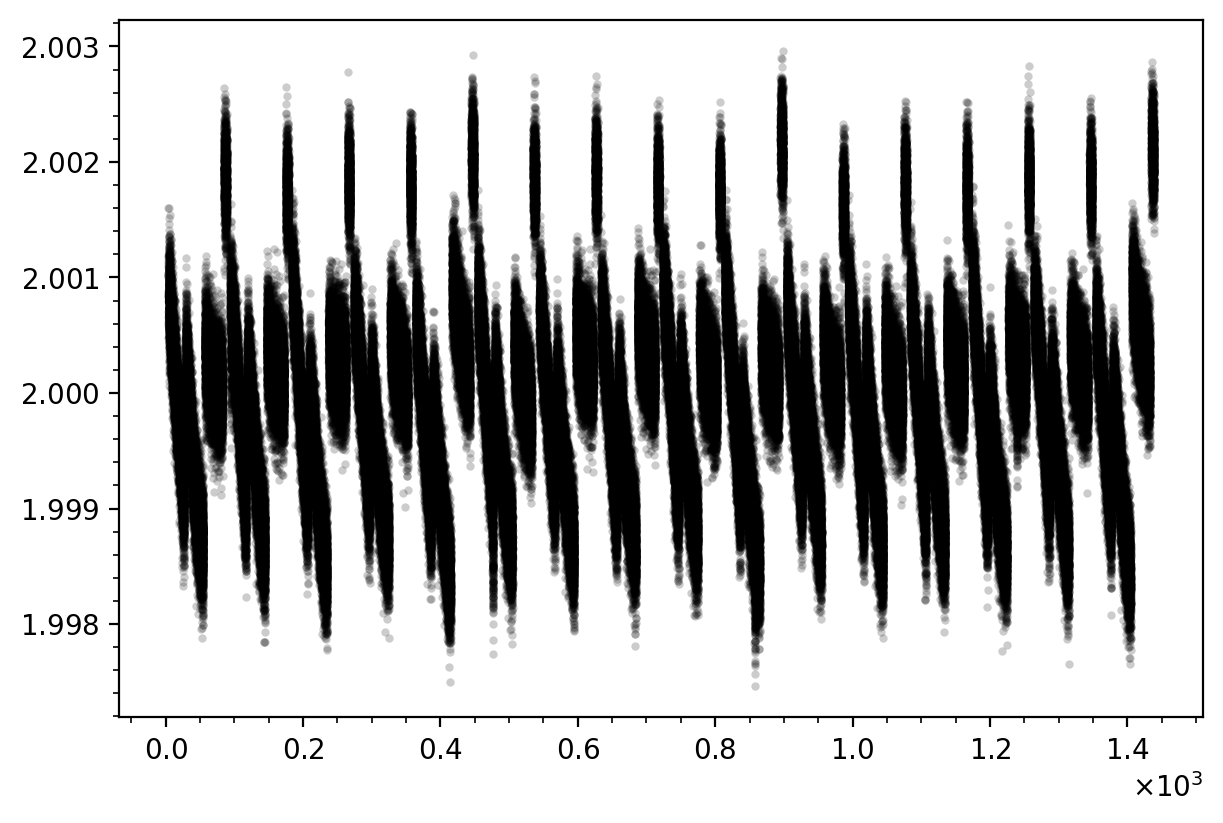

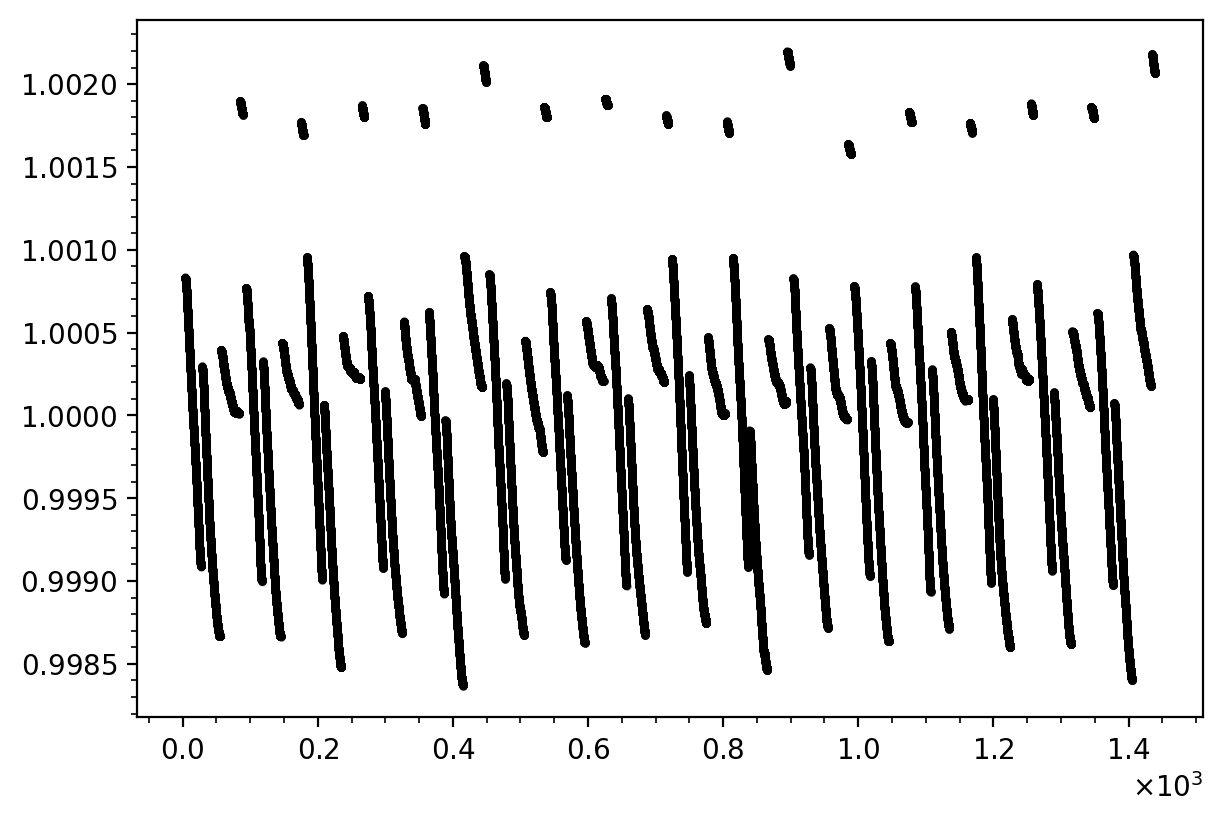

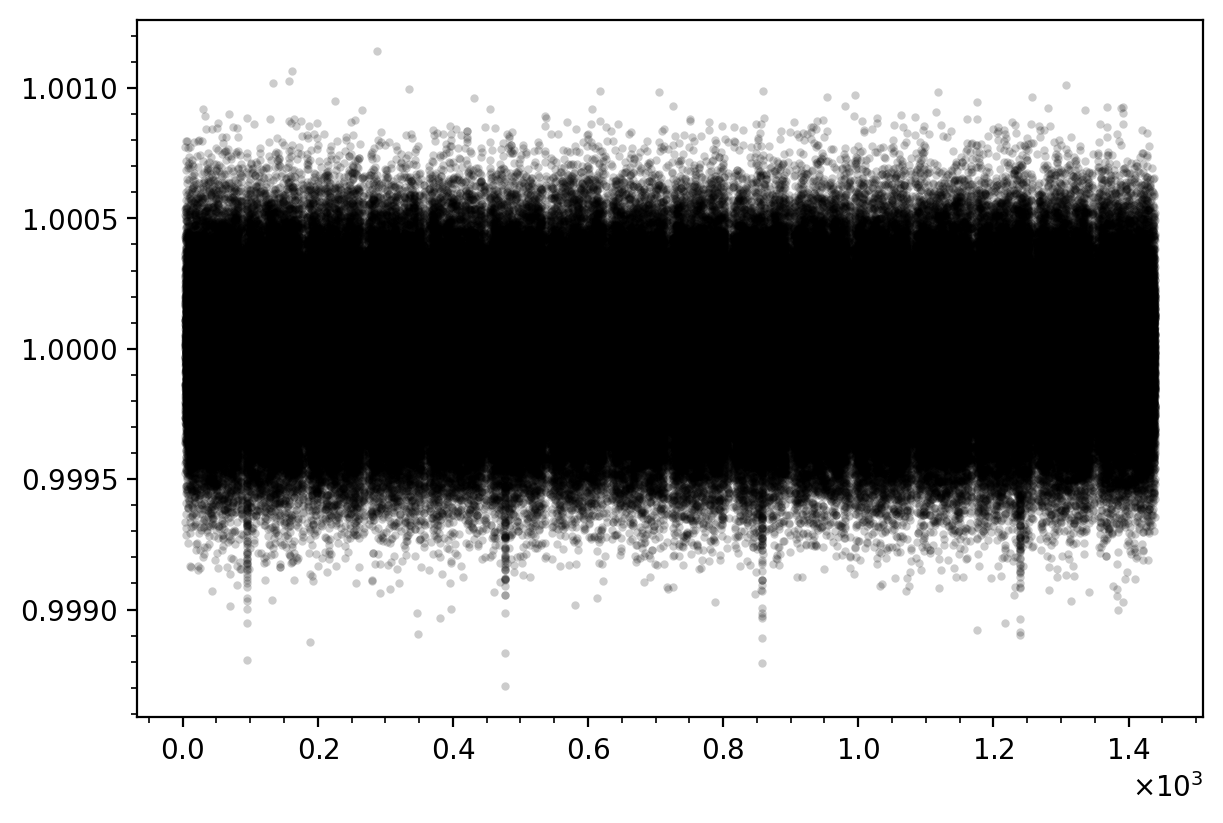

In [9]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from wotan import flatten

index = '00001'

# Open file and extract arrays
flag = f[f'run_{index}/dat/flag'][:]
flux = f[f'run_{index}/dat/flux_var_ppm'][:]
time = f[f'run_{index}/dat/time_s'][:] / (60 * 60 * 24)

# -------------------------------------------------------------------------
# FIX 1: Convert 0-centered ppm variation to a normalized baseline of 1.0
# This prevents the division-by-zero trap when wotan calculates the trend.
# -------------------------------------------------------------------------
flux_norm = 1.0 + (flux / 1e6)

# -------------------------------------------------------------------------
# FIX 2: Find contiguous blocks of data using array transitions
# This groups continuous flagged regions together instead of creating 1-point chunks.
# -------------------------------------------------------------------------
good_mask = (flag == 0.0)
transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
split_indices = np.concatenate(([0], transitions, [len(time)]))

WINDOW = 5.0
EDGE = 1.0

detrend_chunks = []
trend_chunks = []

# Loop over the actual blocks (both good blocks and bad blocks)
for lo, hi in zip(split_indices[:-1], split_indices[1:]):
    
    # If this segment is a flagged/bad block, do not run wotan.
    # Simply fill it with NaNs immediately and skip to the next block.
    if not good_mask[lo]:
        detrend_chunks.append(np.array([np.nan] * (hi - lo)))
        trend_chunks.append(np.array([np.nan] * (hi - lo)))
        continue
        
    # Isolate the clean, unflagged chunk of data
    t_chunk = time[lo:hi]
    f_chunk = flux_norm[lo:hi]
    
    chunk_duration = t_chunk[-1] - t_chunk[0]
    
    # ---------------------------------------------------------------------
    # FIX 3: Dynamic Parameter Protection
    # If a valid chunk is shorter than 1.0 day, turn off the edge cutoff
    # so the chunk doesn't get completely wiped out by the margins.
    # ---------------------------------------------------------------------
    current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
    current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
    if current_window < 0.1: 
        current_window = 0.1
    
    # Run the detrending algorithm on the stable chunk
    tmp_detr, tmp_tr = flatten(
        time=t_chunk,
        flux=f_chunk,
        method='biweight',
        window_length=current_window,
        edge_cutoff=current_edge,
        return_trend=True
    )
    
    detrend_chunks.append(tmp_detr)
    trend_chunks.append(tmp_tr)

# -------------------------------------------------------------------------
# FIX 4: Reassemble the full dataset smoothly using concatenate
# -------------------------------------------------------------------------
detrend = np.concatenate(detrend_chunks)
trend = np.concatenate(trend_chunks)

# Print verification to confirm everything works!
print(f"Total processed shape: {trend.shape}")
print(f"Number of valid numbers in trend: {np.count_nonzero(~np.isnan(trend))}")

plt.plot(time, trend + detrend, 'k.', mec='none', alpha = 0.2)
plt.show()

plt.plot(time, trend, 'k.', mec='none', alpha = 0.2)
plt.show()

plt.plot(time, detrend, 'k.', mec='none', alpha = 0.2)
plt.show()

Total processed shape: (399552,)
Number of valid numbers in trend: 396419


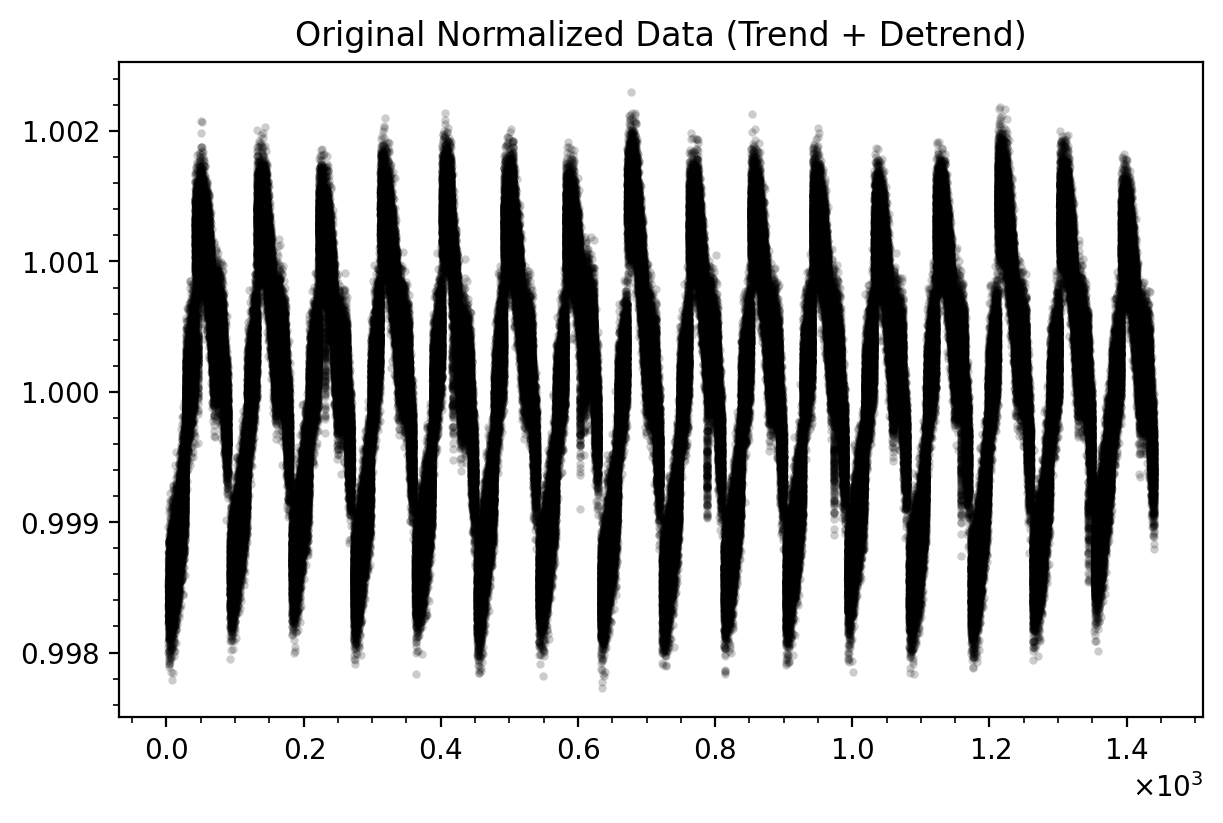

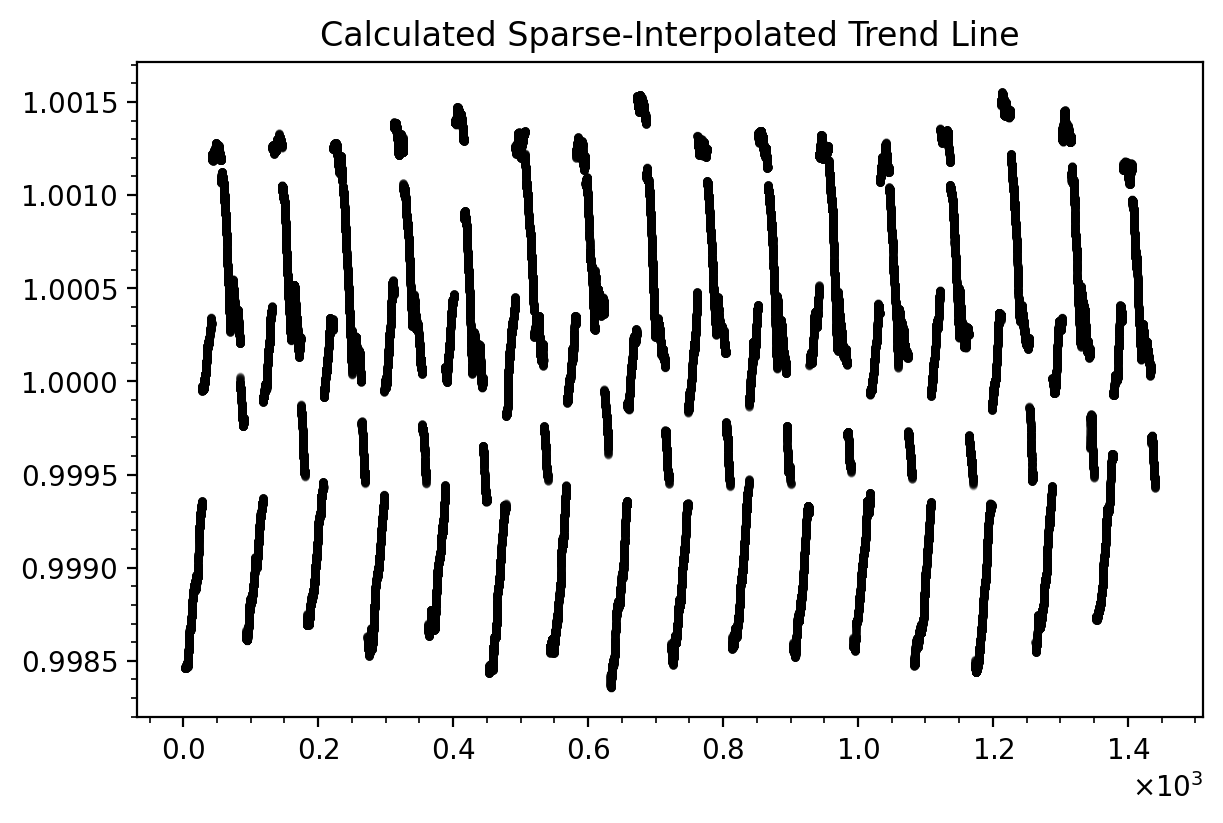

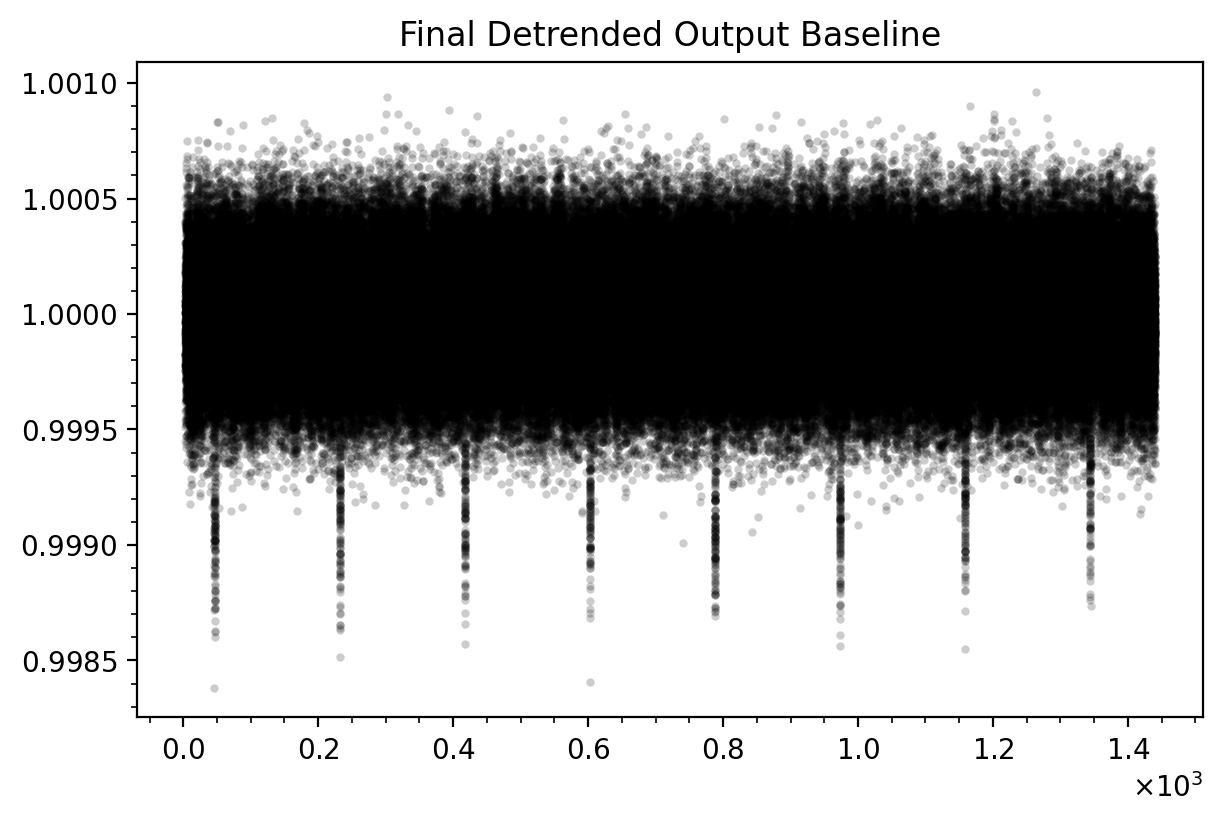

In [65]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from wotan import flatten

index = '00903'

# Open file and extract arrays
# (Assuming 'f' is your open h5py file object)
flag = f[f'run_{index}/dat/flag'][:]
flux = f[f'run_{index}/dat/flux_var_ppm'][:]
time = f[f'run_{index}/dat/time_s'][:] / (60 * 60 * 24)

# -------------------------------------------------------------------------
# FIX 1: Convert 0-centered ppm variation to a normalized baseline of 1.0
# -------------------------------------------------------------------------
flux_norm = 1.0 + (flux / 1e6)

# -------------------------------------------------------------------------
# FIX 2: Find contiguous blocks of data using array transitions
# -------------------------------------------------------------------------
good_mask = (flag == 0.0)
transitions = np.where(np.diff(good_mask.astype(int)) != 0)[0] + 1
split_indices = np.concatenate(([0], transitions, [len(time)]))

WINDOW = 3.0
EDGE = 1/24
STRIDE = 20  # <--- OPTIMIZATION: Process every 20th point for the biweight trend

detrend_chunks = []
trend_chunks = []

# Loop over the actual blocks (both good blocks and bad blocks)
for lo, hi in zip(split_indices[:-1], split_indices[1:]):
    
    # If this segment is a flagged/bad block, do not run wotan.
    if not good_mask[lo]:
        detrend_chunks.append(np.array([np.nan] * (hi - lo)))
        trend_chunks.append(np.array([np.nan] * (hi - lo)))
        continue
        
    # Isolate the clean, unflagged chunk of data
    t_chunk = time[lo:hi]
    f_chunk = flux_norm[lo:hi]
    
    chunk_duration = t_chunk[-1] - t_chunk[0]
    
    # ---------------------------------------------------------------------
    # FIX 3: Dynamic Parameter Protection
    # ---------------------------------------------------------------------
    current_edge = EDGE if chunk_duration > (2 * EDGE) else 0.0
    current_window = WINDOW if chunk_duration > WINDOW else (chunk_duration / 2.0)
    if current_window < 0.1: 
        current_window = 0.1
    
    # ---------------------------------------------------------------------
    # STRIDE OPTIMIZATION: Run Biweight on a Sparse Grid & Interpolate
    # ---------------------------------------------------------------------
    if len(t_chunk) > (STRIDE * 2):
        # 1. Downsample the chunk
        t_sparse = t_chunk[::STRIDE]
        f_sparse = f_chunk[::STRIDE]
        
        # Append the absolute final index if the stride calculation cut it off
        # This protects the chunk boundaries from extrapolation errors
        if (len(t_chunk) - 1) % STRIDE != 0:
            t_sparse = np.append(t_sparse, t_chunk[-1])
            f_sparse = np.append(f_sparse, f_chunk[-1])
            
        # 2. Run wotan exclusively on the tiny sparse subset
        _, tmp_tr_sparse = flatten(
            time=t_sparse,
            flux=f_sparse,
            method='biweight',
            window_length=current_window,
            edge_cutoff=current_edge,
            return_trend=True
        )
        
        # 3. Handle interpolation while preserving the NaN edge_cutoff mask
        good_trend_mask = np.isfinite(tmp_tr_sparse)
        
        if np.any(good_trend_mask):
            valid_times = t_sparse[good_trend_mask]
            t_start, t_end = valid_times[0], valid_times[-1]
            
            # Map sparse trend values back to high resolution
            tmp_tr = np.interp(t_chunk, t_sparse[good_trend_mask], tmp_tr_sparse[good_trend_mask])
            
            # Reinforce NaNs at the edges to perfectly preserve edge_cutoff behavior
            tmp_tr[(t_chunk < t_start) | (t_chunk > t_end)] = np.nan
        else:
            tmp_tr = np.full_like(t_chunk, np.nan)
            
        # Generate the high-resolution detrended chunk
        tmp_detr = f_chunk / tmp_tr

    else:
        # Fallback for ultra-short blocks where striding provides no benefit
        tmp_detr, tmp_tr = flatten(
            time=t_chunk,
            flux=f_chunk,
            method='biweight',
            window_length=current_window,
            edge_cutoff=current_edge,
            return_trend=True
        )
    
    detrend_chunks.append(tmp_detr)
    trend_chunks.append(tmp_tr)

# -------------------------------------------------------------------------
# FIX 4: Reassemble the full dataset smoothly using concatenate
# -------------------------------------------------------------------------
detrend = np.concatenate(detrend_chunks)
trend = np.concatenate(trend_chunks)

# Print verification to confirm everything works!
print(f"Total processed shape: {trend.shape}")
print(f"Number of valid numbers in trend: {np.count_nonzero(~np.isnan(trend))}")

# -------------------------------------------------------------------------
# Diagnostic Plots
# -------------------------------------------------------------------------
plt.plot(time, trend + detrend - 1.0, 'k.', mec='none', alpha=0.2)
plt.title("Original Normalized Data (Trend + Detrend)")
plt.show()

plt.plot(time, trend, 'k.', mec='none', alpha=0.2)
plt.title("Calculated Sparse-Interpolated Trend Line")
plt.show()

plt.plot(time, detrend, 'k.', mec='none', alpha=0.2)
plt.title("Final Detrended Output Baseline")
plt.show()

/tmp/ipykernel_89978/739468795.py:19: RuntimeWarning: invalid value encountered in divide
  binned_flux = (bin_flux / bin_counts)[valid_bins]



--- Wide-Range Safe BLS Search Completed ---
Top Period Candidate:  185.43804 days
Best Epoch T0:         46.32969 days
Transit Duration:      12.00 hours (0.50000 days)
Transit Depth:         710.4 ppm (0.00071 fractional)
Max BLS Power:         0.00
Signal-to-Noise Ratio: 0.01
Actual Seen Transits:  8 (out of 8 theoretical)


/tmp/ipykernel_89978/739468795.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


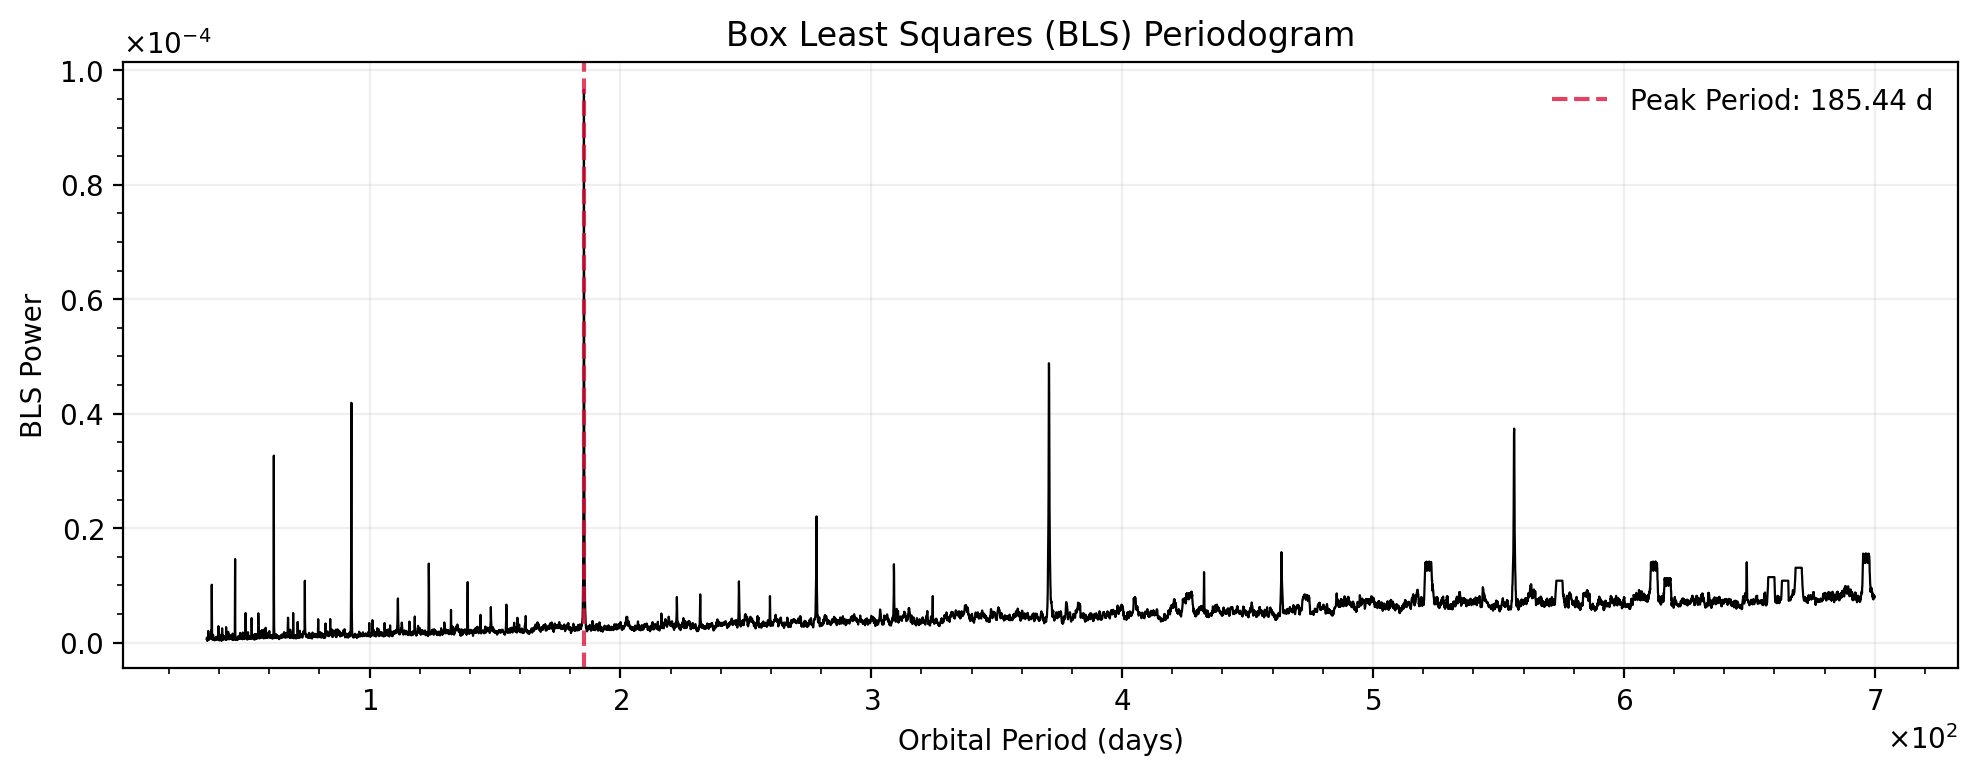

/tmp/ipykernel_89978/739468795.py:117: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


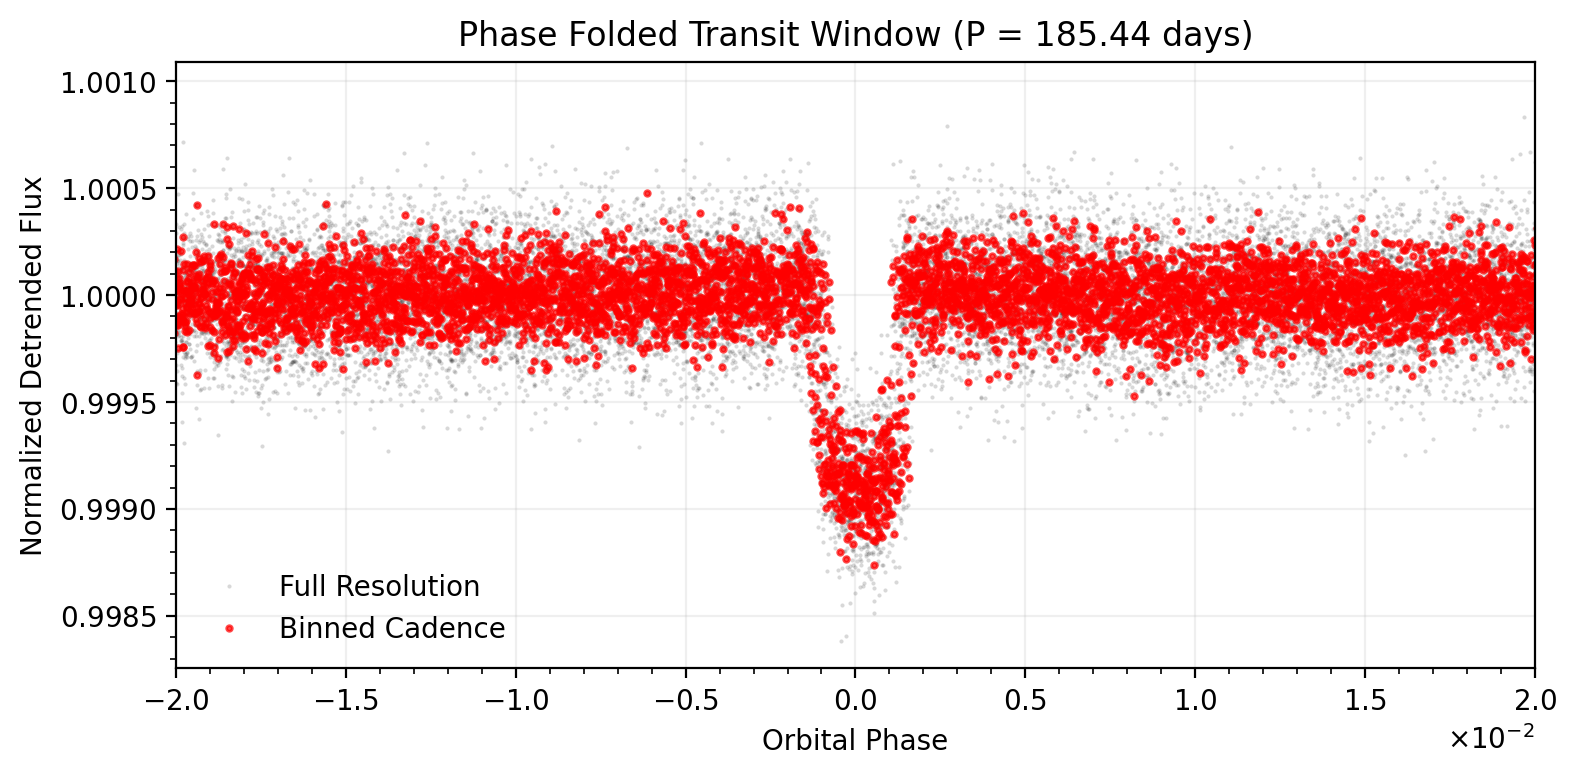

In [66]:
# ... [Your existing code ends here with detrend and trend reassembled] ...

# -------------------------------------------------------------------------
# STEP 1: Fast Binning (2-Hour Cadence: Balanced for 10 to 700 Days)
# -------------------------------------------------------------------------
clean_mask = np.isfinite(time) & np.isfinite(detrend)
tls_time_raw = time[clean_mask]
tls_flux_raw = detrend[clean_mask]

# 2 hours = 2.0 / 24.0 days
bin_size = 0.25 / 24.0 
bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

valid_bins = bin_counts > 0
binned_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
binned_flux = (bin_flux / bin_counts)[valid_bins]

# -------------------------------------------------------------------------
# STEP 2: Define a Safe, Explicit Period Array (Prevents OOM Crashes)
# -------------------------------------------------------------------------
# We hand-craft a grid of 10,000 points. This covers the 10-700 day range 
# beautifully without ever ballooning your laptop's memory.
explicit_periods = np.linspace(35.0, 700.0, 10000)

# Define 5 distinct physical transit durations to check (from 3 to 36 hours)
trial_durations = np.linspace(3.0 / 24.0, 36.0 / 24.0, 5)

# -------------------------------------------------------------------------
# STEP 3: Run BLS via .power() instead of .autopower()
# -------------------------------------------------------------------------
from astropy.timeseries import BoxLeastSquares

model = BoxLeastSquares(binned_time, binned_flux)

# We pass our explicit array and set oversample=1 to prevent internal phase multiplying
results = model.power(
    period=explicit_periods, 
    duration=trial_durations,
    oversample=1 
)

# -------------------------------------------------------------------------
# STEP 4: Extract Winning Parameters & Advanced Stats (Crash-Safe)
# -------------------------------------------------------------------------
max_idx = np.argmax(results.power)
best_period = results.period[max_idx]
best_t0 = results.transit_time[max_idx]

# Pull the precise duration and depth matched at the peak power index
best_duration = results.duration[max_idx]
best_depth = results.depth[max_idx] 

# Calculate native deep-dive validation metrics
stats = model.compute_stats(best_period, best_duration, best_t0)

# Calculate SNR directly from the depth + depth_error tuple
depth_val, depth_err = stats['depth']
calculated_snr = depth_val / depth_err

# Count transits that actually contain data points
actual_transit_count = np.sum(stats['per_transit_count'] > 0)

print(f"\n--- Wide-Range Safe BLS Search Completed ---")
print(f"Top Period Candidate:  {best_period:.5f} days")
print(f"Best Epoch T0:         {best_t0:.5f} days")
print(f"Transit Duration:      {best_duration * 24.0:.2f} hours ({best_duration:.5f} days)")
print(f"Transit Depth:         {best_depth * 1e6:.1f} ppm ({best_depth:.5f} fractional)")
print(f"Max BLS Power:         {results.power[max_idx]:.2f}")
print(f"Signal-to-Noise Ratio: {calculated_snr:.2f}")
print(f"Actual Seen Transits:  {actual_transit_count} (out of {len(stats['transit_times'])} theoretical)")

# -------------------------------------------------------------------------
# STEP 5: Plot the Periodogram
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(results.period, results.power, color='black', lw=0.8)
plt.axvline(best_period, color='crimson', linestyle='--', alpha=0.8, 
            label=f'Peak Period: {best_period:.2f} d')
plt.title("Box Least Squares (BLS) Periodogram")
plt.xlabel("Orbital Period (days)")
plt.ylabel("BLS Power")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# STEP 6: Phase-Fold & Plot the Light Curve Window
# -------------------------------------------------------------------------
# Using 'tls_time_raw' and 'tls_flux_raw' to view the true unbinned dip
phase = ((tls_time_raw - best_t0) % best_period) / best_period

# Shift phases to center the transit profile perfectly at 0.0
phase[phase > 0.5] -= 1.0

plt.figure(figsize=(8, 4))
# Plot raw high-res measurements in the background
plt.plot(phase, tls_flux_raw, 'k.', markersize=1, alpha=0.15, label='Full Resolution')

# Phase-fold and superimpose the binned points to highlight the box structure
binned_phase = ((binned_time - best_t0) % best_period) / best_period
binned_phase[binned_phase > 0.5] -= 1.0
plt.plot(binned_phase, binned_flux, 'r.', markersize=4, alpha=0.7, label='Binned Cadence')

# Tight zoom around the transit window (-5% to +5% phase width)
plt.xlim(-0.02, 0.02)  
plt.title(f"Phase Folded Transit Window (P = {best_period:.2f} days)")
plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Detrended Flux")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
# ... [Your existing code ends here with detrend and trend reassembled] ...

# -------------------------------------------------------------------------
# STEP 1: Strip the NaNs Out Before Feeding TLS
# Your biweight loop explicitly inserts NaNs for bad blocks and edge cutoffs.
# TLS requires clean continuous arrays.
# -------------------------------------------------------------------------
clean_mask = np.isfinite(time) & np.isfinite(detrend)
tls_time = time[clean_mask]
tls_flux = detrend[clean_mask]

# -------------------------------------------------------------------------
# STEP 2: Initialize and Run Single-Pass High-Speed TLS
# -------------------------------------------------------------------------
from transitleastsquares import transitleastsquares

# Load data into the engine
model = transitleastsquares(tls_time, tls_flux)

# Run the single-pass optimized search
results = model.power(
    period_min=40,
    
    # 1. Cap Period Max (Massive Speedup)
    # Default is 730 days (half of 4 years). Dropping this to 50 or 100 days 
    # eliminates millions of redundant long-period permutations.
    period_max=540.0, 
    
    # 2. Coarsen Period Steps (Oversampling)
    # Default is 5. Setting this to 1 matches the analytical Nyquist limit 
    # of the data grid without packing extra redundant steps between peaks.
    oversampling_factor=0.5,
    
    # 3. Reduce Duration Steps
    # Default is 1.05. Raising this to 1.3 geometric steps reduces the checked 
    # duration variations (e.g., from 66 paths down to roughly ~12 paths).
    duration_grid_step=2.0,
    
    # 4. Enforce Transit Count Safeguards
    # In a 4-year dataset, any true planet with a period < 50 days must transit 
    # at least ~29 times. Setting this to 3 filters out spurious single-event anomalies.
    n_transits_min=3,
    
    # 5. Set an Analytical Depth Limit
    # Tells TLS to ignore trying to optimize profiles for dips shallower than 100 ppm.
    transit_depth_min=100e-6
)

# -------------------------------------------------------------------------
# STEP 3: Output Results Uniformly
# -------------------------------------------------------------------------
print(f"\n--- TLS Search Completed ---")
print(f"Top Period Candidate: {results.period:.5f} days")
print(f"Signal Detection Efficiency (SDE): {results.SDE:.2f}")
print(f"Signal-to-Noise Ratio (SNR): {results.snr:.2f}")

if results.SDE > 7.0:
    print("🚀 Significant transit candidate detected!")
else:
    print("Flat lightcurve. No notable signals found.")

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 7 durations
Searching 352958 data points, 4087 periods from 50.013 to 478.299 days
Using all 16 CPU threads




  0%|                                                                                                                                   | 0/4087 periods | 00:00<?

  0%|                                                                                                                             | 1/4087 periods | 00:02<2:35:53

  0%|▏                                                                                                                              | 6/4087 periods | 00:02<20:21

  0%|▎                                                                                                                             | 12/4087 periods | 00:02<08:57

  0%|▌                                                                                                                             | 18/4087 periods | 00:02<05:21

  1%|▊                                                                                                                             | 27/4087 periods | 00:02<03:09

  1%|█▏       

Searching for best T0 for period 286.31078 days




  0%|                                                                                                                                   | 0/36126 [00:00<?, ?it/s]

  0%|                                                                                                                         | 1/36126 [00:00<1:31:08,  6.61it/s]

  0%|                                                                                                                         | 34/36126 [00:00<03:42, 162.36it/s]

  0%|▏                                                                                                                        | 72/36126 [00:00<02:25, 248.45it/s]

  0%|▎                                                                                                                       | 107/36126 [00:00<02:06, 285.06it/s]

  0%|▍                                                                                                                       | 147/36126 [00:00<01:51, 322.55it/s]

  1%|▋        


--- TLS Search Completed ---
Top Period Candidate: 286.31078 days
Signal Detection Efficiency (SDE): 35.54
Signal-to-Noise Ratio (SNR): 62.53
🚀 Significant transit candidate detected!


In [19]:
# ... [Your existing code ends here with detrend and trend reassembled] ...

# -------------------------------------------------------------------------
# STEP 1: Strip NaNs and Downsample Clean Data Aggressively (~15ms)
# For a period search between 40-540 days, a 1-hour cadence is more than enough
# -------------------------------------------------------------------------
clean_mask = np.isfinite(time) & np.isfinite(detrend)
tls_time_raw = time[clean_mask]
tls_flux_raw = detrend[clean_mask]

# Define an aggressive bin size (1 hour = 1.0 / 24.0 days)
bin_size = 1.0 / 24.0 
bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

# Compute fast binned statistics
bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

# Keep only the valid bins that contain actual data points
valid_bins = bin_counts > 0
tls_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
tls_flux = (bin_flux / bin_counts)[valid_bins]

# -------------------------------------------------------------------------
# STEP 2: Run Hyper-Optimized Single-Pass TLS (~2 to 6 seconds)
# -------------------------------------------------------------------------
from transitleastsquares import transitleastsquares

model = transitleastsquares(tls_time, tls_flux)

results = model.power(
    period_min=40.0,
    period_max=540.0, 
    
    # Grid optimization tweaks
    oversampling_factor=0.5,    # Coarse period sampling
    duration_grid_step=1.5,     # Looser transit duration steps
    
    # Performance multipliers
    fast_sky=True,              # CRITICAL: Uses a fast analytic approximation for limb darkening
    use_threads=16,             # Force use of all your laptop's CPU threads
    
    # Statistical safeguards for 4-year data
    n_transits_min=2,           # A 500-day planet will only transit 2-3 times in 4 years
    transit_depth_min=100e-6
)

# -------------------------------------------------------------------------
# STEP 3: Print Output
# -------------------------------------------------------------------------
print(f"\n--- TLS Search Completed ---")
print(f"Top Period Candidate: {results.period:.5f} days")
print(f"Best Epoch T0: {results.T0:.5f} days")
print(f"Signal Detection Efficiency (SDE): {results.SDE:.2f}")

/tmp/ipykernel_87300/2058367682.py:22: RuntimeWarning: invalid value encountered in divide
  tls_flux = (bin_flux / bin_counts)[valid_bins]
/home/fritz/.local/miniforge3/envs/notes/lib/python3.14/site-packages/transitleastsquares/validate.py:57: UserWarning: Ignoring unknown parameter: fast_sky
  warnings.warn(text)


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 12 durations
Searching 29610 data points, 4828 periods from 40.005 to 539.927 days
Using all 16 CPU threads




  0%|                                                                                                                                   | 0/4828 periods | 00:00<?

  0%|                                                                                                                             | 1/4828 periods | 00:02<2:44:57

  1%|▊                                                                                                                             | 31/4828 periods | 00:02<04:00

  2%|██▌                                                                                                                           | 98/4828 periods | 00:02<01:02

  4%|████▌                                                                                                                        | 177/4828 periods | 00:02<00:30

  5%|██████▌                                                                                                                      | 254/4828 periods | 00:02<00:19

  7%|████████▌

Searching for best T0 for period 286.33054 days




  0%|                                                                                                                                   | 0/29610 [00:00<?, ?it/s]

  2%|██▎                                                                                                                    | 574/29610 [00:00<00:05, 5734.06it/s]

  4%|█████                                                                                                                 | 1259/29610 [00:00<00:04, 6389.54it/s]

  7%|███████▊                                                                                                              | 1947/29610 [00:00<00:04, 6610.21it/s]

  9%|██████████▍                                                                                                           | 2633/29610 [00:00<00:04, 6708.10it/s]

 11%|█████████████▏                                                                                                        | 3323/29610 [00:00<00:03, 6777.24it/s]

 14%|█████████


--- TLS Search Completed ---
Top Period Candidate: 286.33054 days
Best Epoch T0: 71.65389 days
Signal Detection Efficiency (SDE): 36.01


In [ ]:
# ... [Your existing code ends here with detrend and trend reassembled] ...

# -------------------------------------------------------------------------
# STEP 1: Fast Binning (2-Hour Cadence: Balanced for Venus to Mars)
# -------------------------------------------------------------------------
clean_mask = np.isfinite(time) & np.isfinite(detrend)
tls_time_raw = time[clean_mask]
tls_flux_raw = detrend[clean_mask]

# 2 hours = 2.0 / 24.0 days = 0.0833 days
bin_size = 2.0 / 24.0 
bin_edges = np.arange(tls_time_raw[0], tls_time_raw[-1] + bin_size, bin_size)

bin_counts, _ = np.histogram(tls_time_raw, bins=bin_edges)
bin_flux, _ = np.histogram(tls_time_raw, bins=bin_edges, weights=tls_flux_raw)

valid_bins = bin_counts > 0
tls_time = (bin_edges[:-1] + bin_size / 2.0)[valid_bins]
tls_flux = (bin_flux / bin_counts)[valid_bins]

# -------------------------------------------------------------------------
# STEP 2: Generate a High-Speed Custom Period Grid
# -------------------------------------------------------------------------
from transitleastsquares import period_grid

# This utility function builds an optimal mathematical grid based on baseline.
# By forcing oversampling_factor very low, we keep the total step count small.
custom_periods = period_grid(
    R_star=1.0,               # Sun-like star approximation
    M_star=1.0,
    time_span=tls_time[-1] - tls_time[0],
    period_min=10.0,          # Expanded downward for short periods
    period_max=700.0,         # Keeps Mars-like orbits
    oversampling_factor=0.1    # CRITICAL: Keeps step count low across the 700-day span
)

print(f"Custom grid generated with {len(custom_periods)} trial periods.")

# -------------------------------------------------------------------------
# STEP 3: Execute Single-Pass TLS using the Custom Grid (~3 to 6 seconds)
# -------------------------------------------------------------------------
from transitleastsquares import transitleastsquares

model = transitleastsquares(tls_time, tls_flux)

results = model.power(
    period_grid=custom_periods,  # Pass our custom array directly
    duration_grid_step=2.0,      # Coarse duration steps for fast execution
    fast_sky=True,               # Use analytical limb darkening
    use_threads=16,              # Engage all logical processor cores
    n_transits_min=2,            # Ensures 500+ day orbits aren't filtered out
    transit_depth_min=100e-6
)

# -------------------------------------------------------------------------
# STEP 4: Print Output
# -------------------------------------------------------------------------
print(f"\n--- Wide-Range TLS Search Completed ---")
print(f"Top Period Candidate: {results.period:.5f} days")
print(f"Best Epoch T0: {results.T0:.5f} days")
print(f"Signal Detection Efficiency (SDE): {results.SDE:.2f}")

/tmp/ipykernel_87300/676109704.py:19: RuntimeWarning: invalid value encountered in divide
  tls_flux = (bin_flux / bin_counts)[valid_bins]


Custom grid generated with 2001 trial periods.
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 10 durations
Searching 14846 data points, 183223 periods from 0.602 to 717.417 days
Using all 16 CPU threads




  0%|                                                                                                                                 | 0/183223 periods | 00:00<?

  0%|                                                                                                                         | 1/183223 periods | 00:02<104:34:45

  0%|                                                                                                                          | 71/183223 periods | 00:02<1:06:27

  0%|                                                                                                                           | 159/183223 periods | 00:02<26:11

  0%|▏                                                                                                                          | 262/183223 periods | 00:02<14:10

  0%|▎                                                                                                                          | 388/183223 periods | 00:02<08:37

  0%|▎        

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from transitleastsquares import transitleastsquares

# 1. Manually filter out the NaN gaps using a boolean mask
# This seamlessly removes the telemetry/flag discontinuities from your timeline
clean_mask = np.isfinite(time) & np.isfinite(detrend)

clean_time = time[clean_mask]
clean_flux = detrend[clean_mask]

# 2. Instantiate the Transit Least Squares search engine
# Note: Ensure you pass your detrended flux (which is normalized around 1.0)
model = transitleastsquares(clean_time, clean_flux)

# 3. Execute the period grid search 
# Tip: Constrain the range to accelerate execution speeds on big datasets
# e.g., model.power(period_min=0.5, period_max=20, use_threads=4)
results = model.power(
    period_min=50.0,
    period_max=500.0,
    oversampling_factor=3,
    duration_grid_step=1.2)

# 4. Review the analytical diagnostic properties of the top candidate
print(f"Best-fit Period: {results.period:.5f} days")
print(f"Best-fit Epoch (T0): {results.T0:.5f} days")
print(f"Transit Duration (T14): {results.duration:.5f} days")
print(f"Transit Depth: {results.depth:.5f}")
print(f"Signal Detection Efficiency (SDE): {results.SDE:.2f}")
print(f"Signal-to-Noise Ratio (SNR): {results.snr:.2f}")

# -------------------------------------------------------------------------
# Plotting the Signal Diagnostics
# -------------------------------------------------------------------------

# Plot A: The Periodogram (SDE spectrum)
plt.figure(figsize=(10, 4))
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(np.min(results.periods), np.max(results.periods))
plt.axhline(7.0, color='red', linestyle='--', alpha=0.7, label='SDE Detection Floor (~7.0)')
plt.xlabel("Period (days)")
plt.ylabel("SDE Power")
plt.title("Transit Least Squares Periodogram")
plt.legend()
plt.show()

# Plot B: Phase-Folded Data Overlaid with the Best-Fit Mandel-Agol Model
plt.figure(figsize=(8, 5))
plt.plot(results.folded_phase, results.folded_y, 'k.', alpha=0.2, mec='none', label='Observed Data')
plt.plot(results.model_folded_phase, results.model_folded_model, color='red', lw=2.5, label='TLS Best-Fit Model')
plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Flux")
plt.title(f"Phase Folded at Period = {results.period:.5f} days")
plt.legend()
plt.show()

TypeError: unsupported operand type(s) for &: 'bool' and 'module'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

# 1. Feed your clean, NaN-masked arrays to the engine
model = BoxLeastSquares(clean_time, clean_flux)

# 2. Define the range of physical transit durations you want to look for.
# For example, searching for transits lasting between 1 hour and 12 hours (converted to days):
durations = np.linspace(1/24, 12/24, 15)

# 3. Call autopower directly, providing your durations and period limits.
# This builds the optimal grid under the hood and executes instantly!
results = model.autopower(
    duration=durations,
    minimum_period=5.0,
    maximum_period=500.0
)

# 4. Extract your winning period
best_period = results.period[np.argmax(results.power)]
print(f"BLS Best Period: {best_period:.5f} days")

# -------------------------------------------------------------------------
# Plotting the BLS Periodogram
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(results.period, results.power, color='navy', lw=0.5)
plt.axvline(best_period, color='orange', linestyle='--', alpha=0.8, label=f'Peak: {best_period:.3f} d')
plt.xlabel("Period (days)")
plt.ylabel("BLS Power")
plt.title("Box Least Squares Periodogram")
plt.legend()
plt.show()

Process ForkServerPoolWorker-360:
Process ForkServerPoolWorker-362:
Process ForkServerPoolWorker-355:
Process ForkServerPoolWorker-363:
Process ForkServerPoolWorker-358:
Process ForkServerPoolWorker-352:
Process ForkServerPoolWorker-357:
Process ForkServerPoolWorker-359:
Process ForkServerPoolWorker-361:
Process ForkServerPoolWorker-356:
Process ForkServerPoolWorker-353:
Process ForkServerPoolWorker-354:
Process ForkServerPoolWorker-346:
Process ForkServerPoolWorker-321:
Process ForkServerPoolWorker-337:
Process ForkServerPoolWorker-350:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process ForkServerPoolWorker-340:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Tr

In [73]:
datasets = ['trainPlanet', 'trainStar', 'realPlanet', 'realStar']

extract_truth = pd.DataFrame()

for dataset in datasets:
    with h5py.File(f'PSLS/data/{dataset}.hdf5', 'r') as hdf:
        print()

group = f['run_00004']

raw_yaml = group.attrs['config_used']
metadata_dict = yaml.safe_load(raw_yaml)
metadata_dict[]

{'Observation': {'QuarterDuration': [90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0,
   90.0],
  'MasterSeed': 3,
  'Gaps': {'Enable': 1,
   'Seed': -1,
   'InterQuarterGapDuration': 3.0,
   'RandomGapDuration': 20.0,
   'RandomGapTimeFraction': 0.05,
   'RandomGapStep': 0.0,
   'PeriodicGapCadence': 5.0,
   'PeriodicGapDuration': 20.0,
   'PeriodicGapJitter': 2.0,
   'PeriodicGapStep': 0.0}},
 'Instrument': {'Sampling': 300.0,
  'IntegrationTime': 252.0,
  'GroupID': [1, 2, 3, 4],
  'NCamera': 6,
  'TimeShift': 6.25,
  'RandomNoise': {'Enable': 1, 'Type': 'PLATO_SIMU', 'NSR': 73.0},
  'Systematics': {'Enable': 1,
   'Table': 'systematics/PLATO_systematics_BOL_V2.npy',
   'Version': 2,
   'DriftLevel': 'any',
   'Seed': -1}},
 'Star': {'Mag': 10.874232839805165,
  'ID': 3,
  'ModelType': 'grid',
  'ModelDir': 'models/',
  'ModelName': 'grid.hdf5',
  'ES': 'ms',
  'Teff': 5767.55585035373,
  'Logg': 4.45

np.False_